# TUGAS 2 : KLASIFIKASI

Muhammad Hidayat

``` yaml
Nama: Muhammad Hidayat
NIM: 052747132
```

# 1. Pendahuluan

Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang
memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan
pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam.
Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk
sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi
tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan
strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan
lulus tepat waktu.

Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat
model yang mampu mendeteksi secara dini tingkat risiko kegagalan seorang
mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang
valid, maka bagian wali akademik dapat memberikan konseling yang tepat.
Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari
dua periode penerimaan.

Tugas ini dibagi ke beberapa poin tugas:

1.  Memuat semua data yang ada ke dalam sistem.
2.  Memetakan perbedaan data yang ada, lalu menanganinya.
3.  Menyatukan data dan menangani masalah kodifikasi atribut fitur yang
    berbeda.
4.  Melakukan analisis atribut untuk setiap fiturnya, seperti:
    - menangani *missing value*
    - menangani data duplikat
    - menangani data yang tidak valid
    - dll.
5.  Melakukan visualisasi distribusi untuk setiap fitur, dilanjutkan
    dengan menangani *outlier*.
6.  Melihat hubungan setiap fitur dengan kelas target, untuk mendapatkan
    fitur yang relevan.
7.  Mengidentifikasi ketidakimbangan data, menentukan algoritma, dan
    menangani *imbalance* jika diperlukan, kemudian membagi data
    *training* dan *testing*.
8.  Melakukan *training* model dan evaluasi model.
9.  Melakukan prediksi dan evaluasi model terhadap data *testing*.
10. Memberikan kesimpulan berdasarkan hasil evaluasi.

# 2. Persiapan Lingkungan

## 2.1 Library yang Digunakan

Sebelum memulai, import library yang diperlukan untuk melakukan proses
data cleaning, data visualization, dan machine learning.

In [1]:
# 1) Import library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

Berikut penjelasan singkat mengenai library yang diimport:

- `numpy`: Library untuk melakukan operasi matematika dan manipulasi
  array.
- `pandas`: Library untuk manipulasi data dan analisis data, terutama
  dengan struktur DataFrame.
- `matplotlib.pyplot`: Library untuk membuat visualisasi data, seperti
  grafik dan plot.

### 2.1.1 Fungsi Helper

Berikut adalah definisi fungsi `info_like` yang digunakan untuk
merangkum kolom data dengan format tabel yang rapi:

In [2]:
def info_like(df: pd.DataFrame):
    # 1) Build the summary DataFrame
    summary = pd.DataFrame({
        "#": range(len(df.columns)),
        "column": df.columns,
        "non-null": df.notna().sum().values,
        "dtype": df.dtypes.astype(str).values,
    })

    # 2) Build the dtype counts markdown string
    dtype_counts = df.dtypes.astype(str).value_counts()
    dtype_md_lines = [f"- `{dt}`: {cnt}" for dt, cnt in dtype_counts.items()]
    dtype_md = "\n".join(dtype_md_lines)

    return summary, dtype_md

## 2.2 Pemuatan Data (Tugas 1)

Mulailah memuat semua data yang ada ke sistem.

In [3]:
# 1) Muat data dari kedua sumber
data_period1 = pd.read_csv('Data Siswa Periode 1.csv')
data_period2 = pd.read_csv('Data Siswa Periode 2.csv')

In [4]:
# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
print("Atribut Data Periode 1:\n")
for col in data_period1.columns.tolist():
    print(f"- {col}")
print("\nAtribut Data Periode 2:\n")
for col in data_period2.columns.tolist():
    print(f"- {col}")

Atribut Data Periode 1:

- ID
- Status Pernikahan
- Program Studi
- Kelas Reguler/Malam
- Pendidikan Terakhir
- Nilai SMA
- Daerah Asal
- Pendidikan Ibu
- Pendidikan Ayah
- Pekerjaan Ibu
- Pekerjaan Ayah
- Nilai Ujian Masuk
- Pindahan
- Berkebutuhan Khusus
- Status pembayaran semester terakhir
- Jenis Kelamin
- Beasiswa
- Usia saat mendaftar
- IP Semester 1
- IP Semester 2
- Target

Atribut Data Periode 2:

- ID
- Status Pernikahan
- Program Studi
- Kelas Siang/Malam
- Pendidikan Terakhir
- Nilai SMA
- Daerah Asal
- Pendidikan Ibu
- Pendidikan Ayah
- Pekerjaan Ibu
- Pekerjaan Ayah
- Nilai Ujian Masuk
- Pindahan
- Berkebutuhan Khusus
- Status pembayaran semester terakhir
- Jenis Kelamin
- Beasiswa
- Umur saat mendaftar
- IP Semester 1
- IP Semester 2
- Target


Di atas merupakan daftar kolom yang muncul pada kedua data. Berikut
penjelasan kolom-kolom penting:

- Kelas Reguler/Malam (Kelas Siang/Malam pada data periode 2): waktu
  kelas yang diambil
- Usia saat mendaftar (Umur saat mendaftar pada data periode 2): usia
  siswa saat mendaftar
- IP Semester 1/2: IP mahasiswa pada semester 1 dan 2. Dataset ini hanya
  memberikan dua semester pertama, dan diminta untuk menentukan target
  berdasarkan dua semester tersebut dan parameter lainnya.
- Target: target evaluasi model, menentukan apakah siswa akan “Lulus
  Tepat Waktu”, “Lulus Tidak Tepat Waktu”, atau “Gagal” (Tidak Lulus).

Sebagian kolom terlihat sama, tetapi ada beberapa yang berbeda nama,
padahal maknanya sama. Kita akan melakukan penamaan ulang pada
<a href="#sec-feature-rename" class="quarto-xref">Bagian 3.2</a>.

Selanjutnya kita juga perlu melihat beberapa baris data untuk memastikan
bahwa data sudah benar-benar termuat dengan baik. Karena data memiliki
banyak kolom, kita akan memilih beberapa kolom untuk ditampilkan agar
tidak terlalu lebar, dan kita akan menampilkan data periode 1 dan data
periode 2 secara terpisah agar lebih mudah untuk dibandingkan.

In [5]:
# 3) Lihat beberapa baris data untuk memastikan data sudah benar-benar termuat dengan baik

# Pilih beberapa kolom untuk ditampilkan agar tidak terlalu lebar
cols_to_display = ['ID', 'Program Studi', 'Kelas Reguler/Malam', 'IP Semester 1', 'IP Semester 2', 'Target']
cols_to_display_2 = ['ID', 'Program Studi', 'Kelas Siang/Malam', 'IP Semester 1', 'IP Semester 2', 'Target']

display(data_period1[cols_to_display].head())
display(data_period2[cols_to_display_2].head())

,ID,Program Studi,Kelas Reguler/Malam,IP Semester 1,IP Semester 2,Target
0,2,Teknik Industri,Reguler,2.48,2.52,Lulus Tepat Waktu
1,3,Jurnalistik,Reguler,2.86,2.63,Lulus Tepat Waktu
2,4,Pertanian,Reguler,2.20,2.07,Lulus Tidak Tepat Waktu
3,5,Teknik Mesin,Reguler,2.60,2.40,Lulus Tidak Tepat Waktu
4,10,Perbankan,Reguler,2.61,2.72,Lulus Tepat Waktu


,ID,Program Studi,Kelas Siang/Malam,IP Semester 1,IP Semester 2,Target
0,1817,Perbankan,Siang,2.63,2.63,Lulus Tidak Tepat Waktu
1,1819,Teknik Industri,Siang,2.42,0.00,Gagal
2,1820,Akuntansi,Siang,2.00,0.00,Gagal
3,1821,Perbankan,Siang,2.57,3.10,Lulus Tepat Waktu
4,1822,Teknik Industri,Siang,0.00,0.00,Gagal


Kemudian kita juga perlu melihat informasi statistik serta tipe data
dari setiap kolom untuk memastikan bahwa data sudah benar-benar termuat
dengan baik dan mampu memberikan informasi yang cukup untuk melakukan
proses analisis data selanjutnya.

Berikut informasi statistik dan tipe data dari setiap kolom pada kedua
data tersebut. Di sini menggunakan fungsi `info_like` (@fn:info_like)
agar `info()` tampil lebih rapi.

In [6]:
info_period1_summary, info_period1_dtype_md = info_like(data_period1)
info_period2_summary, info_period2_dtype_md = info_like(data_period2)

# 4) Lihat informasi statistik dan tipe data dari setiap kolom
display(info_period1_summary)

,#,column,non-null,dtype
0,0,ID,1827,int64
1,1,Status Pernikahan,1827,str
2,2,Program Studi,1827,str
3,3,Kelas Reguler/Malam,1824,str
4,4,Pendidikan Terakhir,1827,str
5,5,Nilai SMA,1827,float64
6,6,Daerah Asal,1824,str
7,7,Pendidikan Ibu,1827,str
8,8,Pendidikan Ayah,1827,str
9,9,Pekerjaan Ibu,1827,str


In [7]:
display(data_period1.describe())

,ID,Nilai SMA,Nilai Ujian Masuk,Usia saat mendaftar,IP Semester 1,IP Semester 2
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000
mean,903.234811,66.221483,63.573837,23.550082,2.143706,2.053848
std,527.157905,6.571933,7.331973,8.515695,0.953743,1.028765
min,1.000000,47.500000,47.500000,-39.000000,0.000000,0.000000
25%,446.500000,62.000000,58.925000,19.000000,2.200000,2.185000
50%,903.000000,66.500000,63.000000,20.000000,2.460000,2.440000
75%,1359.500000,70.000000,67.750000,26.000000,2.680000,2.670000
max,1816.000000,94.000000,95.000000,70.000000,3.600000,3.540000


In [8]:
display(info_period2_summary)

,#,column,non-null,dtype
0,0,ID,1730,int64
1,1,Status Pernikahan,1730,str
2,2,Program Studi,1730,str
3,3,Kelas Siang/Malam,1730,str
4,4,Pendidikan Terakhir,1730,str
5,5,Nilai SMA,1730,float64
6,6,Daerah Asal,1730,str
7,7,Pendidikan Ibu,1730,str
8,8,Pendidikan Ayah,1730,str
9,9,Pekerjaan Ibu,1730,str


In [9]:
display(data_period2.describe())

,ID,Nilai SMA,Nilai Ujian Masuk,Umur saat mendaftar,IP Semester 1,IP Semester 2
count,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000
mean,2670.671676,66.527832,63.530809,22.856069,2.124659,2.050150
std,499.261281,6.536001,7.099820,7.169725,0.976162,1.051431
min,1817.000000,48.000000,47.500000,17.000000,0.000000,0.000000
25%,2238.250000,62.500000,59.000000,18.000000,2.200000,2.150000
50%,2670.500000,66.550000,63.150000,20.000000,2.470000,2.450000
75%,3102.750000,70.000000,67.387500,24.000000,2.680000,2.690000
max,3535.000000,95.000000,95.000000,61.000000,3.780000,3.710000


In [ ]:
print("Tipe data pada Data Periode 1:\n")
print(info_period1_dtype_md)
print("\nTipe data pada Data Periode 2:\n")
print(info_period2_dtype_md)


Terdapat 1827 entri pada data periode 1 dan 1730 entri pada data periode 2. Kolom-kolom yang muncul pada kedua data tersebut sebagian besar
memiliki tipe data string, namun terdapat beberapa kolom yang memiliki
tipe data numerik. Kolom seperti ID, nilai, usia/umur, dan IP memiliki
tipe data numerik. Kolom yang lain semuanya memiliki tipe data string
dan terlihat seperti data kategorikal. Detail lebih lanjut akan dibahas
di bagian yang relevan.

# 3. Integrasi & Pembersihan Data

## 3.1 Penanganan Missing Value (Task 2a)

Dari deskripsi statistik di atas, terlihat bahwa terdapat beberapa kolom
pada data periode 1 yang memiliki nilai null/missing value, sementara
pada data periode 2 tidak terdapat nilai null/missing value. Kita perlu
melakukan penanganan untuk mengatasi masalah ini agar nantinya tidak
terjadi masalah saat melakukan proses integrasi data.

Terlebih dahulu kita hitung dan identifikasi jumlah nilai null/missing
value untuk setiap kolom pada data periode 1.

In [10]:
# Filter baris dengan nilai NA
na_rows_d1 = data_period1[data_period1.isnull().any(axis=1)]

# Hitung jumlah total nilai NA
total_cols_na = data_period1.isnull().sum()
# Hitung baris dengan nilai NA
total_rows_na = na_rows_d1.shape[0]

total_na = data_period1.isnull().sum().sum()

# Cetak jumlah nilai NA per kolom
print("Count of NA values per column:")
print(total_cols_na[total_cols_na > 0])

# Cetak jumlah total baris dengan nilai NA
print(f"Total count of rows with NA values: {total_rows_na}")

# Cetak jumlah total nilai NA
print(f"Total count of NA values: {total_na}")

# Cetak baris dengan nilai NA
print("Rows with NA values:")
display(na_rows_d1[cols_to_display])

Count of NA values per column:
Kelas Reguler/Malam    3
Daerah Asal            3
dtype: int64
Total count of rows with NA values: 6
Total count of NA values: 6
Rows with NA values:


,ID,Program Studi,Kelas Reguler/Malam,IP Semester 1,IP Semester 2,Target
658,1317,Agronomi,NaN,2.43,2.50,Lulus Tepat Waktu
724,1424,Perbankan,Reguler,2.61,2.61,Lulus Tepat Waktu
1121,382,Jurnalistik,Reguler,2.80,2.93,Lulus Tepat Waktu
1368,924,Penyiaran,Reguler,2.58,2.90,Lulus Tepat Waktu
1624,1456,Manajemen,NaN,2.83,2.70,Lulus Tepat Waktu
1764,1719,Akuntansi,NaN,2.00,0.00,Gagal


Secara spesifik, terdapat 3 entri null pada “Kelas Reguler/Malam” dan 3
entri null pada “Daerah Asal”. Kemudian, terdapat 6 baris yang memiliki
nilai null dan total 6 nilai null, berarti terdapat tepat satu nilai
null pada kolom yang berbeda.

Dan karena banyaknya nilai null yang relatif sedikit, kita bisa
melakukan penanganan dengan menghapus baris yang memiliki nilai null
tersebut agar nantinya tidak terjadi masalah saat melakukan proses
integrasi data.

In [11]:
# Hapus baris dengan nilai NA
data_period1_clean = data_period1.dropna()
# Verifikasi bahwa nilai NA sudah dihapus
print("Jumlah nilai NA setelah pembersihan:")
print(data_period1_clean.isnull().sum())

# Banyak baris setelah pembersihan
print(f"Banyak baris setelah pembersihan: {data_period1_clean.shape[0]}")

Jumlah nilai NA setelah pembersihan:
ID                                     0
Status Pernikahan                      0
Program Studi                          0
Kelas Reguler/Malam                    0
Pendidikan Terakhir                    0
Nilai SMA                              0
Daerah Asal                            0
Pendidikan Ibu                         0
Pendidikan Ayah                        0
Pekerjaan Ibu                          0
Pekerjaan Ayah                         0
Nilai Ujian Masuk                      0
Pindahan                               0
Berkebutuhan Khusus                    0
Status pembayaran semester terakhir    0
Jenis Kelamin                          0
Beasiswa                               0
Usia saat mendaftar                    0
IP Semester 1                          0
IP Semester 2                          0
Target                                 0
dtype: int64
Banyak baris setelah pembersihan: 1821


Setelah pembersihan, jumlah nilai null sudah tidak ada lagi pada data
periode 1, dan banyak baris setelah pembersihan menjadi 1821 entri. Kita
bisa melanjutkan ke proses selanjutnya, yaitu identifikasi fitur yang
serupa dan penamaan ulang agar kedua dataset memiliki atribut yang
seragam.

## 3.2 Penamaan Ulang Fitur (Task 2b)

Sebelum melakukan analisis lebih lanjut, kita perlu memastikan bahwa
data yang kita miliki sudah bersih dan siap untuk digunakan. Salah satu
langkah penting dalam proses ini adalah mengidentifikasi fitur yang
serupa dan melakukan penamaan ulang agar kedua dataset memiliki atribut
yang seragam.

In [12]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa

# Bandingkan kedua data untuk melihat apakah ada perbedaan atribut

# Gunakan operasi set untuk mencari perbedaan atribut
_cols_in_period12 = set(data_period1_clean.columns.tolist()) & set(data_period2.columns.tolist())
_cols_in_period1 = set(data_period1_clean.columns.tolist()) - set(data_period2.columns.tolist())
_cols_in_period2 = set(data_period2.columns.tolist()) - set(data_period1_clean.columns.tolist())

# Tampilkan hasil perbandingan atribut
print("\nAtribut yang ada di kedua data:\n")
for col in _cols_in_period12:
    print(f"- {col}")
print("\nAtribut yang hanya ada di data periode 1:\n")
for col in _cols_in_period1:
    print(f"- {col}")
print("\nAtribut yang hanya ada di data periode 2:\n")
for col in _cols_in_period2:
    print(f"- {col}")


Atribut yang ada di kedua data:

- Pindahan
- Nilai SMA
- IP Semester 1
- Pekerjaan Ayah
- Pendidikan Terakhir
- ID
- Program Studi
- Jenis Kelamin
- Pekerjaan Ibu
- Nilai Ujian Masuk
- Target
- Status Pernikahan
- Daerah Asal
- Beasiswa
- Berkebutuhan Khusus
- Status pembayaran semester terakhir
- Pendidikan Ayah
- IP Semester 2
- Pendidikan Ibu

Atribut yang hanya ada di data periode 1:

- Usia saat mendaftar
- Kelas Reguler/Malam

Atribut yang hanya ada di data periode 2:

- Umur saat mendaftar
- Kelas Siang/Malam


Terdapat dua atribut yang berbeda nama namun memiliki makna yang sama,
yaitu “Kelas Reguler/Malam” dengan “Kelas Siang/Malam”, serta “Usia saat
mendaftar” dengan “Umur saat mendaftar”. Kita perlu melakukan penamaan
ulang agar kedua data tersebut memiliki atribut yang seragam. Untuk kali
ini kita akan melakukan penamaan ulang pada data periode 2 agar sesuai
dengan data periode 1, sehingga nantinya kita bisa melakukan proses
integrasi data dengan lebih mudah.

In [13]:
# 2) Lakukan penamaan ulang pada atribut yang berbeda nama namun memiliki makna yang sama
data_period2_ren = data_period2.rename(columns={
    'Kelas Siang/Malam': 'Kelas Reguler/Malam',
    'Umur saat mendaftar': 'Usia saat mendaftar'
})

Untuk memastikan bahwa penamaan ulang sudah benar, kita bisa melihat
kembali atribut yang ada pada data periode 2 setelah dilakukan penamaan
ulang.

In [14]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa

# Bandingkan kedua data untuk melihat apakah ada perbedaan atribut

# Gunakan operasi set untuk mencari perbedaan atribut
_cols_in_period12ren = set(data_period1_clean.columns.tolist()) & set(data_period2_ren.columns.tolist())
_cols_in_period1ren = set(data_period1_clean.columns.tolist()) - set(data_period2_ren.columns.tolist())
_cols_in_period2ren = set(data_period2_ren.columns.tolist()) - set(data_period1_clean.columns.tolist())

# Tampilkan hasil perbandingan atribut
print("\nAtribut yang ada di kedua data:\n")
for col in _cols_in_period12ren:
    print(f"- {col}")
print("\nAtribut yang hanya ada di data periode 1:\n")
for col in _cols_in_period1ren:
    print(f"- {col}")
print("\nAtribut yang hanya ada di data periode 2:\n")
for col in _cols_in_period2ren:
    print(f"- {col}")


Atribut yang ada di kedua data:

- Pindahan
- Usia saat mendaftar
- Nilai SMA
- IP Semester 1
- Kelas Reguler/Malam
- Pekerjaan Ayah
- Pendidikan Terakhir
- ID
- Program Studi
- Jenis Kelamin
- Pekerjaan Ibu
- Nilai Ujian Masuk
- Target
- Status Pernikahan
- Daerah Asal
- Beasiswa
- Berkebutuhan Khusus
- Status pembayaran semester terakhir
- Pendidikan Ayah
- IP Semester 2
- Pendidikan Ibu

Atribut yang hanya ada di data periode 1:


Atribut yang hanya ada di data periode 2:



Terlihat tidak ada lagi perbedaan atribut antara kedua data setelah
dilakukan penamaan ulang, sehingga kita bisa melanjutkan ke proses
selanjutnya, yaitu penyamaan kodefikasi atribut fitur yang berbeda pada
kedua data tersebut.

## 3.3 Penyelarasan Kodefikasi (Task 3a)

kodefikasi  
pengalihan suatu data, keterangan, atau informasi menjadi kode atau
simbol yang dapat dipahami.[1]

Jika sebelumnya kita melakukan penamaan ulang pada atribut yang berbeda
nama namun memiliki makna yang sama, kali ini kita akan menyamakan
kodifikasi atribut fitur yang berbeda. Misalnya untuk atribut “Kelas
Reguler/Malam” pada data periode 1 menggunakan kodifikasi “Reguler” dan
“Malam”, sedangkan pada data periode 2 menggunakan kodifikasi “Siang”
dan “Malam”. Kita perlu menyamakan kodifikasi tersebut agar nantinya
kita bisa melakukan proses integrasi data dengan lebih mudah.

Dari <a href="#sec-data-loading" class="quarto-xref">Bagian 2.2</a>,
kita tahu kolom yang merupakan tipe angka adalah “ID”, “Nilai SMA”,
“Nilai Ujian Masuk”, “Umur saat mendaftar”, “IP Semester 1”, dan “IP
Semester 2”. Kolom ini tidak akan kita proses untuk kodifikasi.
Sedangkan untuk kolom yang lain semuanya memiliki tipe data string,
sehingga kita perlu melakukan proses kodifikasi untuk kolom-kolom
tersebut agar nantinya kita bisa melakukan proses integrasi data dengan
lebih mudah.

[1] Badan Pengembangan dan Pembinaan Bahasa. (t.t.). *Kodefikasi*. Dalam
*Kamus Besar Bahasa Indonesia Daring*. Diakses 13 Mei, 2026, dari
<https://kbbi.kemendikdasmen.go.id/entri/kodefikasi>.

In [15]:
# Identifikasi kodifikasi atribut yang berbeda untuk semua kolom

# Hitung jumlah entri string unik per kolom
unique_entries_d1 = data_period1_clean.apply(lambda col: col.nunique())
unique_entries_d2 = data_period2_ren.apply(lambda col: col.nunique())

# Cetak hasilnya
print("Jumlah entri string unik per kolom:")
print("Data Periode 1:")
display(unique_entries_d1)
print("Data Periode 2:")
display(unique_entries_d2)

Jumlah entri string unik per kolom:
Data Periode 1:


ID                                     1810
Status Pernikahan                         3
Program Studi                            16
Kelas Reguler/Malam                       2
Pendidikan Terakhir                       2
Nilai SMA                                84
Daerah Asal                               2
Pendidikan Ibu                            4
Pendidikan Ayah                           4
Pekerjaan Ibu                             4
Pekerjaan Ayah                            4
Nilai Ujian Masuk                       486
Pindahan                                  2
Berkebutuhan Khusus                       2
Status pembayaran semester terakhir       2
Jenis Kelamin                             2
Beasiswa                                  2
Usia saat mendaftar                      51
IP Semester 1                           125
IP Semester 2                           120
Target                                    3
dtype: int64

Data Periode 2:


ID                                     1719
Status Pernikahan                         3
Program Studi                            16
Kelas Reguler/Malam                       2
Pendidikan Terakhir                       2
Nilai SMA                                81
Daerah Asal                               2
Pendidikan Ibu                            4
Pendidikan Ayah                           4
Pekerjaan Ibu                             4
Pekerjaan Ayah                            4
Nilai Ujian Masuk                       473
Pindahan                                  2
Berkebutuhan Khusus                       2
Status pembayaran semester terakhir       2
Jenis Kelamin                             2
Beasiswa                                  2
Usia saat mendaftar                      42
IP Semester 1                           121
IP Semester 2                           124
Target                                    3
dtype: int64

Di atas menunjukkan banyaknya kodifikasi untuk setiap kolom, baik yang
memiliki tipe data numerik maupun string.

Untuk ID, terdapat kejanggalan. Terdapat 1821 entri dalam data periode
1, namun hanya terdapat 1816 ID unik. Sementara itu untuk data periode 2
terdapat 1730 entri dan 1719 ID unik. Hal ini menunjukkan bahwa terdapat
beberapa ID yang duplikat pada kedua data tersebut, dan akan ditangani
dalam
<a href="#sec-handle-duplicates" class="quarto-xref">Bagian 3.5</a>.

Selanjutnya kita akan melihat apa saja entri unik untuk setiap kolom,
khususnya yang bertipe string, untuk melihat apakah ada perbedaan
kodifikasi yang perlu disamakan.


In [16]:
# Filter kolom yang memiliki tipe data string
string_cols = data_period1_clean.select_dtypes(include=['str']).columns.tolist()
# Tidak perlu dua kali karena sudah dipastikan sama setelah penamaan ulang
#string_cols_d2 = data_period2_ren.select_dtypes(include=['str']).columns.tolist()

# Filter entri string unik untuk setiap kolom pada kedua data
str_entries_d1 = data_period1_clean[string_cols].apply(lambda col: col.unique())
str_entries_d2 = data_period2_ren[string_cols].apply(lambda col: col.unique())

# Gunakan operasi set untuk mencari perbedaan atribut
_entries_differ = []
for col in string_cols:
    if set(str_entries_d1[col]) != set(str_entries_d2[col]):
        _entries_differ.append(col)

# Tampilkan hasil perbandingan entri string unik
# print jika _entries_differ tidak kosong
if len(_entries_differ) > 0:
    print("\nPerbedaan Entri String Unik:\n")
    print("Kolom | Data Periode 1 | Data Periode 2")
    print("------|----------------|----------------")
    for col in _entries_differ:
        print(f"{col} | {str_entries_d1[col].tolist()} | {str_entries_d2[col].tolist()}")


Perbedaan Entri String Unik:

Kolom | Data Periode 1 | Data Periode 2
------|----------------|----------------
Kelas Reguler/Malam | ['Reguler', 'Malam'] | ['Siang', 'Malam']
Jenis Kelamin | ['Pria', 'Wanita'] | ['Laki-laki', 'Perempuan']



Sama seperti sebelumnya, kita akan menyamakan kodifikasi pada data
periode 2 agar sesuai dengan data periode 1.

In [17]:
# Lakukan penyamaan kodifikasi atribut
data_period2_clean = data_period2_ren.replace({
  'Kelas Reguler/Malam': {'Siang': 'Reguler'},
  'Jenis Kelamin': {'Laki-laki': 'Pria', 'Perempuan': 'Wanita'}
})

Kita konfirmasi kembali untuk memastikan bahwa penyamaan kodifikasi
sudah benar.


In [18]:

# Filter entri string unik untuk setiap kolom pada kedua data
str_entries_d1c = data_period1_clean[string_cols].apply(lambda col: col.unique())
str_entries_d2c = data_period2_clean[string_cols].apply(lambda col: col.unique())

# Gunakan operasi set untuk mencari perbedaan atribut
_entries_differ = []
for col in string_cols:
    if set(str_entries_d1c[col]) != set(str_entries_d2c[col]):
        _entries_differ.append(col)

# Tampilkan hasil perbandingan entri string unik
# print jika _entries_differ tidak kosong
if len(_entries_differ) > 0:
    print("\nPerbedaan Entri String Unik:\n")
    print("Kolom | Data Periode 1 | Data Periode 2")
    print("------|----------------|----------------")
    for col in _entries_differ:
        print(f"{col} | {str_entries_d1[col].tolist()} | {str_entries_d2[col].tolist()}")




Tidak lagi tampak ada perbedaan entri string unik pada kedua data
setelah dilakukan penyamaan kodifikasi, sehingga kita bisa melanjutkan
ke proses selanjutnya, yaitu penyatuan data.

## 3.4 Penggabungan Dataset (Task 3b)

Setelah melakukan proses penamaan ulang dan penyamaan kodifikasi, kita
bisa melanjutkan ke proses penyatuan data. Kita akan menggunakan fungsi
`concat` dari library `pandas` untuk menyatukan kedua data tersebut
menjadi satu data yang utuh.

In [19]:
# 2) Lakukan penyatuan data
data_unified = pd.concat([data_period1_clean, data_period2_clean], ignore_index=True)

# 3) Verifikasi bahwa data sudah berhasil disatukan dengan melihat beberapa baris data
display(data_unified[cols_to_display].head())
display(data_unified[cols_to_display].tail())

,ID,Program Studi,Kelas Reguler/Malam,IP Semester 1,IP Semester 2,Target
0,2,Teknik Industri,Reguler,2.48,2.52,Lulus Tepat Waktu
1,3,Jurnalistik,Reguler,2.86,2.63,Lulus Tepat Waktu
2,4,Pertanian,Reguler,2.20,2.07,Lulus Tidak Tepat Waktu
3,5,Teknik Mesin,Reguler,2.60,2.40,Lulus Tidak Tepat Waktu
4,10,Perbankan,Reguler,2.61,2.72,Lulus Tepat Waktu


,ID,Program Studi,Kelas Reguler/Malam,IP Semester 1,IP Semester 2,Target
3546,1833,Ekonomi,Malam,2.53,2.63,Lulus Tidak Tepat Waktu
3547,1834,Perbankan,Reguler,2.73,2.95,Lulus Tepat Waktu
3548,1836,Ekonomi,Malam,2.40,2.69,Lulus Tidak Tepat Waktu
3549,1837,Jurnalistik,Reguler,2.46,2.83,Lulus Tepat Waktu
3550,1842,Perbankan,Reguler,2.79,2.79,Lulus Tepat Waktu


## 3.5 Penanganan Data Duplikat (Task 3c)

Sebagaimana yang sudah disebutkan sebelumnya, terdapat beberapa ID yang
duplikat pada kedua data tersebut. Kita perlu melakukan penanganan agar
nantinya tidak terjadi masalah saat melakukan proses analisis data
selanjutnya.

Langkah pertama adalah mendapatkan baris duplikat dan menghitungnya.

In [20]:
# Get duplicate rows
duplicate_rows = data_unified[data_unified.duplicated()]
print(f"Jumlah baris duplikat: {len(duplicate_rows)}")

Jumlah baris duplikat: 22


Terdapat 22 baris duplikat dalam data yang telah diintegrasikan.
Pertama-tama kita akan melihat beberapa baris duplikat tersebut,
kemudian kita akan menghapus baris duplikat tersebut agar nantinya tidak
terjadi masalah saat melakukan proses analisis data selanjutnya.

In [21]:
# Tampilkan beberapa baris duplikat untuk verifikasi
display(duplicate_rows[cols_to_display].sort_values(by='ID').head(10))

,ID,Program Studi,Kelas Reguler/Malam,IP Semester 1,IP Semester 2,Target
1813,29,Teknik Mesin,Reguler,3.14,2.89,Lulus Tepat Waktu
1814,30,Manajemen,Reguler,2.34,2.08,Lulus Tidak Tepat Waktu
1815,31,Teknologi Informasi,Reguler,2.35,2.40,Gagal
1816,32,Perpajakan,Reguler,2.40,2.10,Gagal
909,33,Ekonomi,Malam,2.27,2.23,Gagal
1817,34,Jurnalistik,Reguler,2.25,2.27,Lulus Tepat Waktu
1818,35,Perpajakan,Reguler,3.30,3.54,Gagal
1819,36,Perbankan,Reguler,2.47,2.47,Lulus Tepat Waktu
932,37,Akuntansi,Reguler,2.27,0.00,Gagal
1820,38,Manajemen,Reguler,2.53,2.60,Lulus Tepat Waktu


Selanjutnya kita akan menghapus baris duplikat.

In [22]:
# Hapus baris duplikat
data_unified_dedup = data_unified.drop_duplicates()

Konfirmasi bahwa baris duplikat sudah dihapus dengan melihat jumlah
baris sebelum dan sesudah penghapusan duplikat.

In [23]:
# Get unique counts for each column in the unified data
for column in data_unified_dedup.columns:
    unique_counts = data_unified_dedup[column].value_counts()
    print(f"Unique counts for column '{column}':\n{unique_counts}\nTotal: {unique_counts.sum()}\n")

Unique counts for column 'ID':
ID
2       1
3       1
4       1
5       1
10      1
       ..
3525    1
3527    1
3528    1
3529    1
3533    1
Name: count, Length: 3529, dtype: int64
Total: 3529

Unique counts for column 'Status Pernikahan':
Status Pernikahan
Belum Menikah    3122
Menikah           305
Cerai             102
Name: count, dtype: int64
Total: 3529

Unique counts for column 'Program Studi':
Program Studi
Perbankan              598
Hubungan Masyarakat    315
Agronomi               281
Teknik Mesin           267
Jurnalistik            248
Akuntansi              221
Ekonomi                212
Pertanian              200
Perpustakaan           178
Pariwisata             178
Penyiaran              176
Manajemen              175
Teknologi Informasi    150
Perpajakan             142
Keperawatan            116
Teknik Industri         72
Name: count, dtype: int64
Total: 3529

Unique counts for column 'Kelas Reguler/Malam':
Kelas Reguler/Malam
Reguler    3141
Malam       388
Name: c

# 4. Eksplorasi Data (EDA)

## 4.1 Analisis Statistik (Task 4)

Setelah membuang data duplikat, kita bisa melakukan analisis data untuk
melihat informasi dari data, dan menentukan apakah masih perlu
penanganan data lebih lanjut.

In [24]:
info_dedup_summary, info_dedup_dtype_md = info_like(data_unified_dedup)

display(info_dedup_summary)

,#,column,non-null,dtype
0,0,ID,3529,int64
1,1,Status Pernikahan,3529,str
2,2,Program Studi,3529,str
3,3,Kelas Reguler/Malam,3529,str
4,4,Pendidikan Terakhir,3529,str
5,5,Nilai SMA,3529,float64
6,6,Daerah Asal,3529,str
7,7,Pendidikan Ibu,3529,str
8,8,Pendidikan Ayah,3529,str
9,9,Pekerjaan Ibu,3529,str


In [25]:
print("Tipe data pada Data Unifikasi tanpa duplikat:\n")
print(info_dedup_dtype_md)


Tipe data pada Data Unifikasi tanpa duplikat:

- `str`: 15
- `float64`: 4
- `int64`: 2



Tipe data pada Data Unifikasi tanpa duplikat:

- `str`: 15
- `float64`: 4
- `int64`: 2

Tabel 14: Rincian Tipe Data Gabungan

In [26]:
display(data_unified_dedup.describe())

,ID,Nilai SMA,Nilai Ujian Masuk,Usia saat mendaftar,IP Semester 1,IP Semester 2
count,3529.000000,3529.000000,3529.000000,3529.000000,3529.000000,3529.000000
mean,1768.959479,66.357481,63.536526,23.200623,2.131179,2.049065
std,1021.054052,6.557385,7.219416,7.894643,0.967413,1.041178
min,1.000000,47.500000,47.500000,-39.000000,0.000000,0.000000
25%,884.000000,62.500000,58.950000,19.000000,2.200000,2.160000
50%,1771.000000,66.550000,63.100000,20.000000,2.470000,2.440000
75%,2653.000000,70.000000,67.500000,25.000000,2.680000,2.670000
max,3535.000000,95.000000,95.000000,70.000000,3.780000,3.710000


Dari ringkasan statistik, terlihat bahwa terdapat beberapa nilai yang
tidak masuk akal pada kolom “Usia saat mendaftar”, di mana usia mencapai
nilai negatif seperti -39. Meskipun terdapat usia yang tinggi seperti
70, namun masih mungkin terjadi (*plausible*), meskipun sangat jarang.
Untuk kali ini, kita hanya akan menghapus data yang memiliki nilai usia
negatif.

In [27]:
# hapus baris dengan usia di bawah 0
data_unified_clean_age = data_unified_dedup[data_unified_dedup['Usia saat mendaftar'] >= 0]

# konfirmasi bahwa data dengan usia negatif sudah dihapus
display(data_unified_clean_age['Usia saat mendaftar'].describe())

count    3522.000000
mean       23.296990
std         7.594325
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Usia saat mendaftar, dtype: float64

## 4.2 Visualisasi Distribusi (Task 5)

Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram
dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan
penanganan *outlier*.

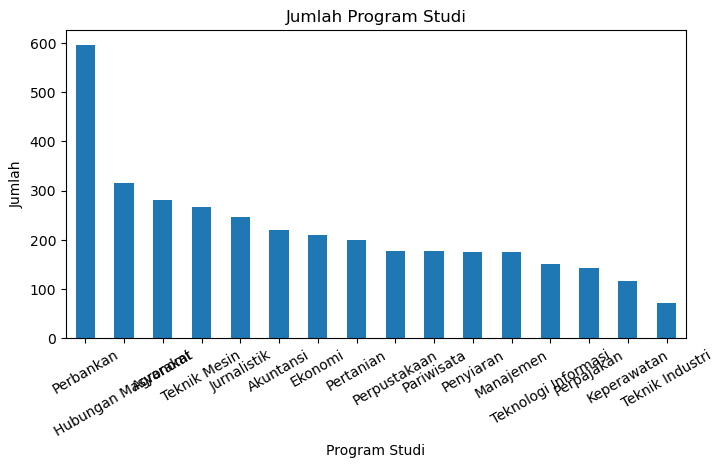

In [28]:
# 1)    Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
# buat grafik khusus untuk Program Studi
plt.figure(figsize=(8, 4))
data_unified_clean_age['Program Studi'].value_counts().plot(kind='bar')
plt.title('Jumlah Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah')
plt.xticks(rotation=30)
plt.show()

Dari grafik di atas, terlihat bahwa program studi Perbankan mendominasi
jumlah mahasiswa, hingga hampir dua kali lipat program studi lainnya.
Setelah itu, perlahan menurun hingga Teknik Industri dengan jumlah di
bawah 100.

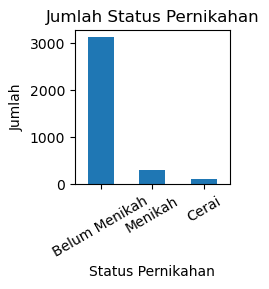

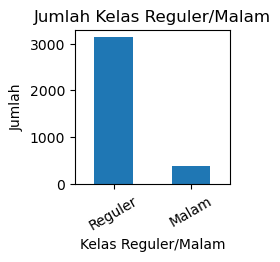

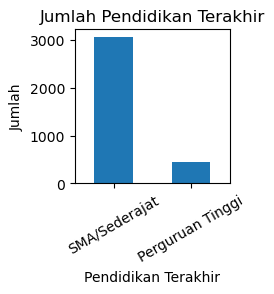

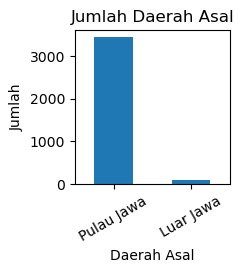

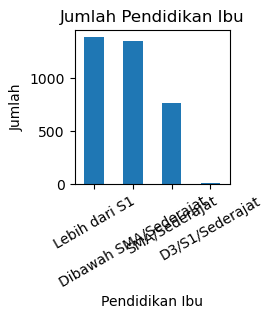

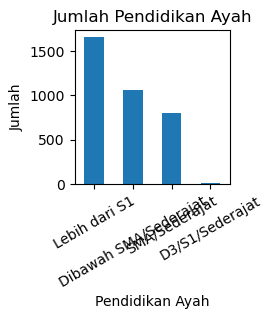

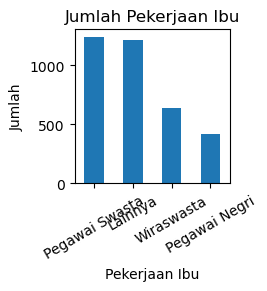

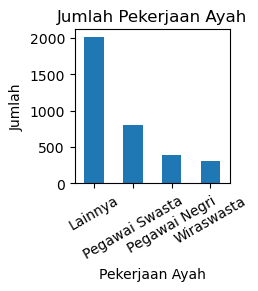

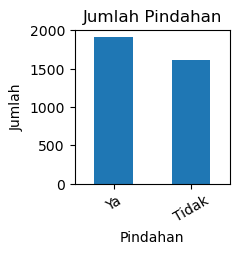

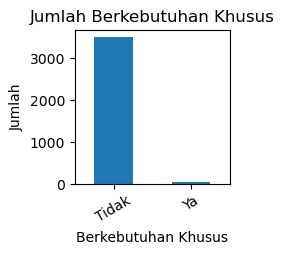

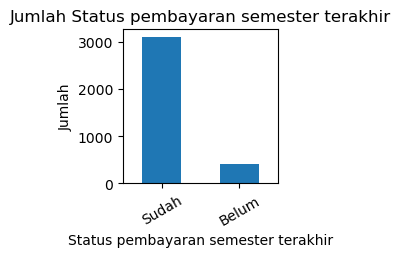

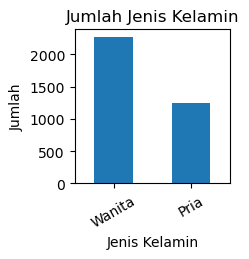

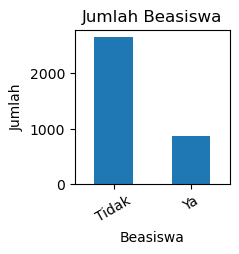

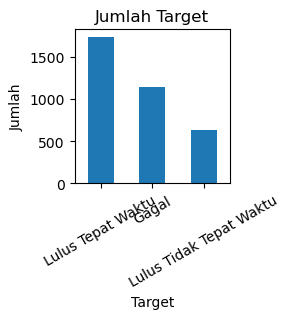

In [29]:
# buat grafik untuk fitur string lainnya
# catatan: untuk subplot diatur oleh blok Jupyter

# buang program studi; akan ditampilkan terpisah dan pertama
string_cols_for_chart = [col for col in string_cols if col != 'Program Studi']

# Untuk tiap fitur kategorikal, buat subplot dalam bentuk grafik batang
for col in string_cols_for_chart:
    plt.figure(figsize=(2, 2))
    data_unified_clean_age[col].value_counts().plot(kind='bar')
    plt.title(f'Jumlah {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=30)
    plt.show()

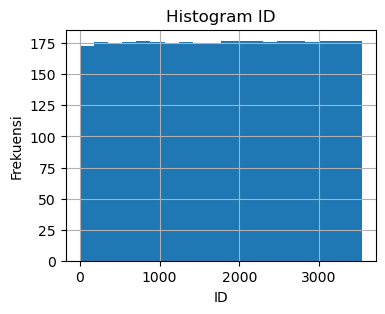

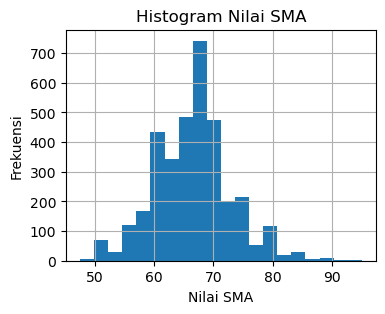

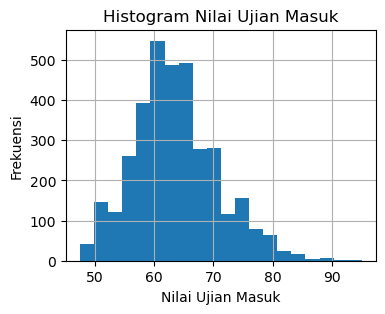

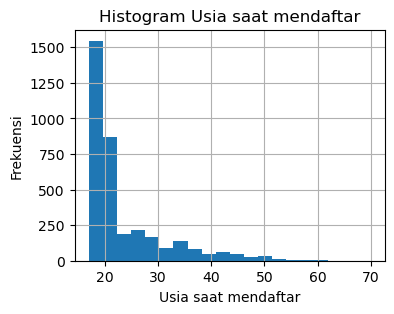

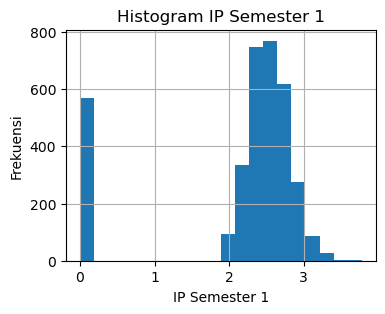

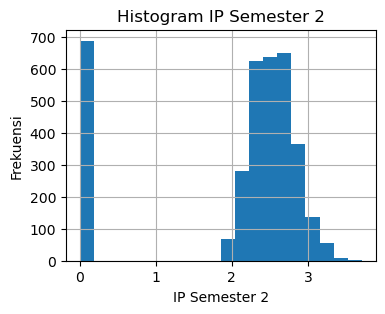

In [30]:
# buat grafik histogram untuk fitur numerik
numeric_cols = data_unified_dedup.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    data_unified_clean_age[col].hist(bins=20)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()


Histogram menunjukkan hal-hal berikut:

- ID tersebar rata, tidak ada yang mendominasi. Distribusi *uniform*.
- Nilai SMA dan Nilai Ujian Masuk memiliki distribusi yang mirip, yaitu
  *skew* ke kanan. Untuk Nilai SMA dominan di daerah 58-65 dengan puncak
  di 60, sedangkan Nilai Ujian Masuk di daerah 65-70 dengan puncak di
  67.
- Usia saat mendaftar terlihat hampir seperti eksponensial, namun lebih
  tepat dikatakan bahwa ini adalah distribusi normal dengan *skew* ke
  kanan drastis. Mayoritas usia saat mendaftar berada di bawah 25,
  dengan puncak di sekitar 18-19 tahun. Namun terdapat ekor panjang
  hingga usia 70.
- IP Semester 1 dan IP Semester 2 memiliki nilai *cutoff* di mana nilai
  hanya 0 atau 2.0 ke atas, dengan sedikit nilai di antara 0 dan 2.0.
  Mayoritas IP berada di atas 2.0, dengan puncak di sekitar 2.5,
  terlihat seperti distribusi normal dengan *skew* ke kanan.



## 4.3 Analisis Hubungan Fitur (Task 6)

Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita
melihat hubungan setiap fitur dengan kelas target.

In [31]:
# 1)    Lakukan analisis bivariate
# cross-tab untuk fitur kategorikal (kecuali Target)
for col in [c for c in string_cols if c != 'Target']:
    crosstab = pd.crosstab(data_unified_clean_age[col], data_unified_clean_age['Target'])
    display(crosstab)


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Status Pernikahan,,,
Belum Menikah,951,1586,580
Cerai,51,33,18
Menikah,144,119,40


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Program Studi,,,
Agronomi,52,199,29
Akuntansi,74,107,39
Ekonomi,108,60,41
Hubungan Masyarakat,114,112,89
Jurnalistik,69,150,28
Keperawatan,65,34,17
Manajemen,44,97,34
Pariwisata,59,102,17
Penyiaran,66,77,33


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Kelas Reguler/Malam,,,
Malam,166,161,58
Reguler,980,1577,580


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Pendidikan Terakhir,,,
Perguruan Tinggi,206,176,72
SMA/Sederajat,940,1562,566


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Daerah Asal,,,
Luar Jawa,25,42,18
Pulau Jawa,1121,1696,620


...

Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Pindahan,,,
Tidak,603,716,290
Ya,543,1022,348


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Berkebutuhan Khusus,,,
Tidak,1134,1723,632
Ya,12,15,6


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Status pembayaran semester terakhir,,,
Belum,364,21,31
Sudah,782,1717,607


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Jenis Kelamin,,,
Pria,581,428,243
Wanita,565,1310,395


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Beasiswa,,,
Tidak,1033,1090,535
Ya,113,648,103


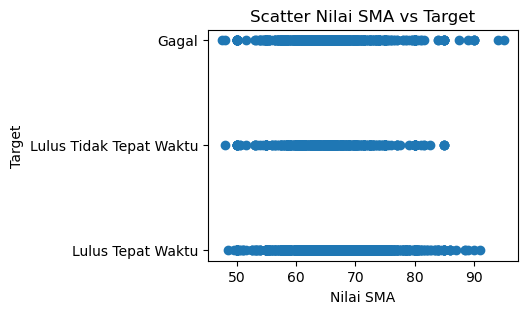

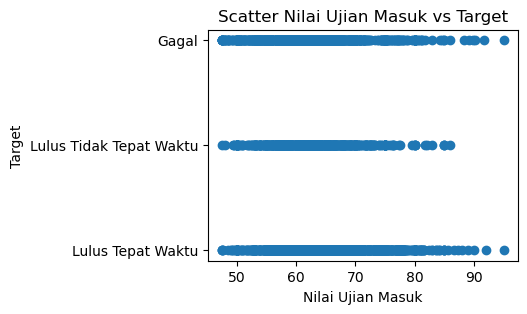

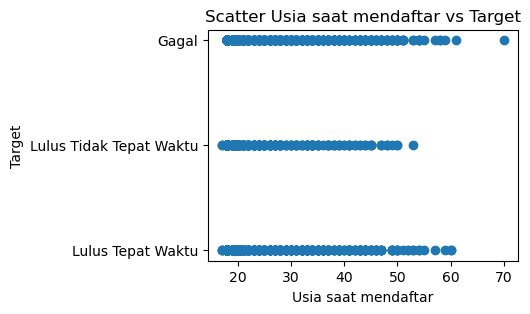

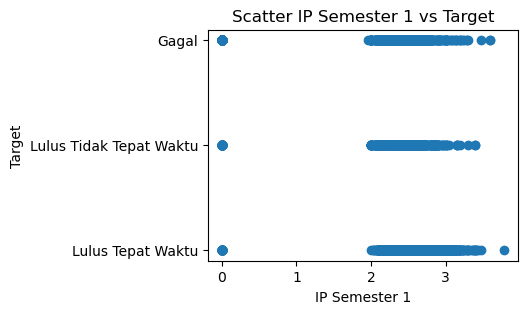

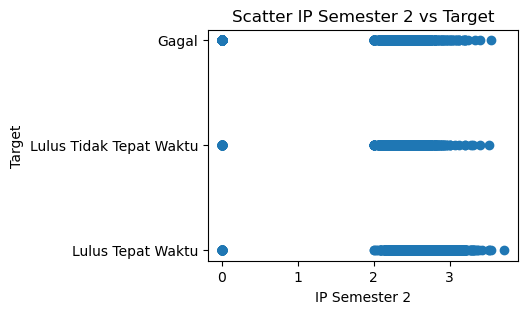

In [32]:
# 2)    Plot kedalam grafik sebaran (scatter)

# buat grafik scatter untuk semua fitur kecuali ID terhadap target
for col in [c for c in numeric_cols if c != 'ID' and c != 'Target']:
    plt.figure(figsize=(4, 3))
    plt.scatter(data_unified_clean_age[col], data_unified_clean_age['Target'])
    plt.title(f'Scatter {col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Target')
    plt.show()


*Scatter plot* menunjukkan IP semester 1 dan 2 memiliki *cutoff* di mana
nilai hanya $0$ atau $2.0$ ke atas.

Untuk analisis *skew*, kita bisa menggunakan metode statistik seperti
*skewness* untuk mengukur tingkat *skew* pada distribusi data. Khususnya
untuk IP Semester 1 dan IP Semester 2, data dengan IP 0 perlu dibuang
agar mendapatkan distribusi yang lebih normal, karena IP 0 kemungkinan
besar merupakan data yang tidak valid atau *outlier* yang ekstrem. Data
dengan IP 0 tetap akan dipertahankan untuk analisis lainnya serta untuk
proses *training* dan *testing*, karena ini bisa jadi merupakan data
yang valid untuk kelas target “Gagal” (Tidak Lulus).

In [33]:
# drop values from IP Semester 1 dan IP Semester 2 if they're 0
data_skew_analysis = data_unified_clean_age[(data_unified_clean_age['IP Semester 1'] > 0) & (data_unified_clean_age['IP Semester 2'] > 0)]

skew_results = data_skew_analysis.skew(numeric_only=True)

display(skew_results)

ID                     0.012328
Nilai SMA              0.197192
Nilai Ujian Masuk      0.485160
Usia saat mendaftar    2.254583
IP Semester 1          0.383436
IP Semester 2          0.366168
dtype: float64

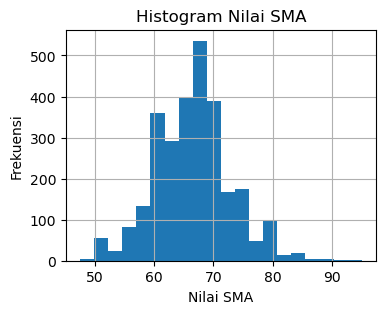

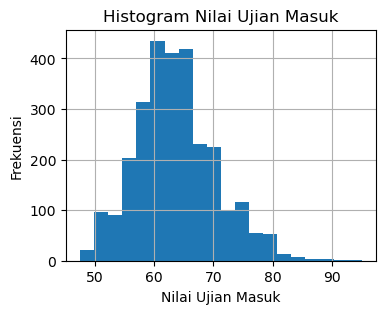

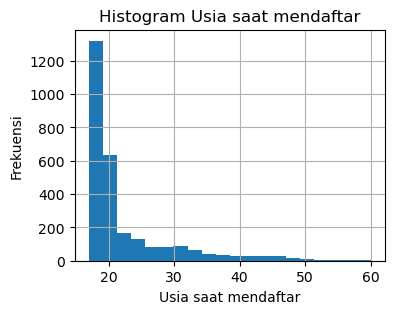

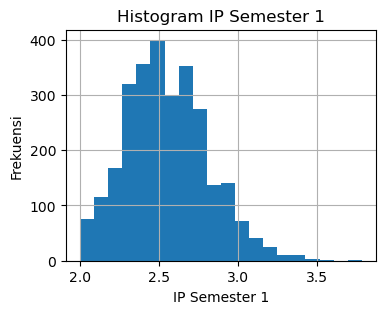

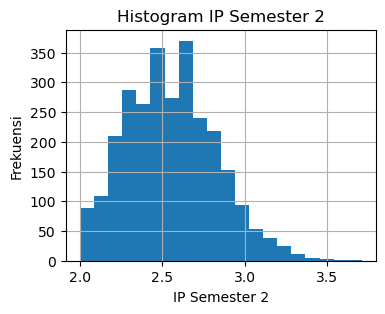

In [34]:
# buat grafik histogram untuk fitur numerik
numeric_cols_no_id = [col for col in numeric_cols if col != 'ID']
for col in numeric_cols_no_id:
    plt.figure(figsize=(4, 3))
    data_skew_analysis[col].hist(bins=20)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

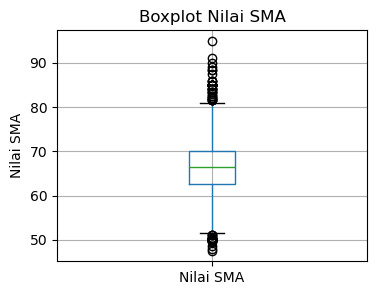

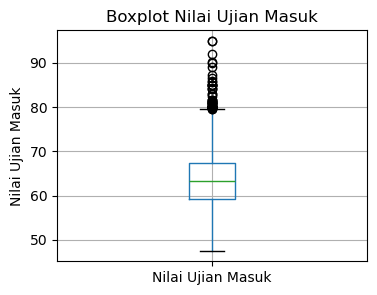

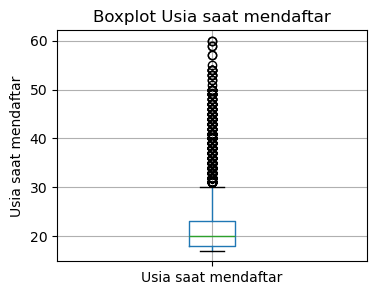

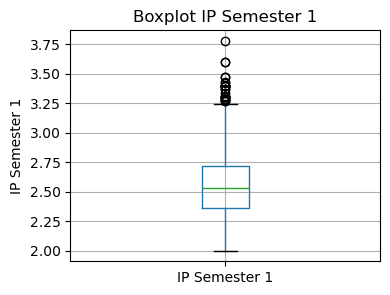

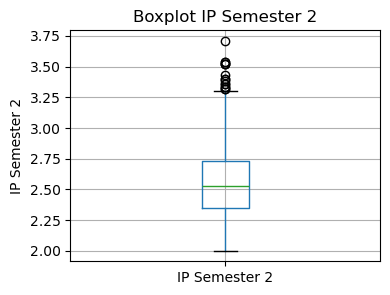

In [35]:
# 2)    Identifikasi outlier dengan boxplot
for col in numeric_cols_no_id:
    plt.figure(figsize=(4, 3))
    data_skew_analysis.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
    plt.show()

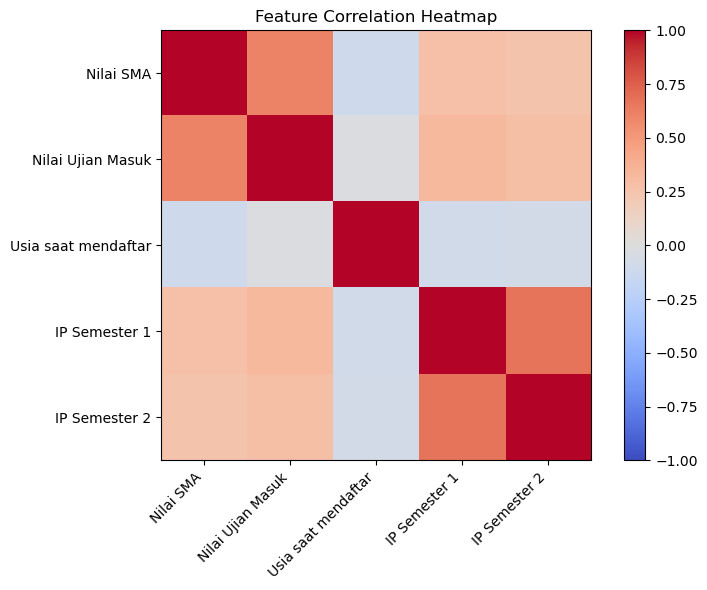

In [36]:
corr = data_skew_analysis[numeric_cols_no_id].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4.4 Preprocessing Data untuk Pemodelan

Sebelum melatih model *machine learning*, data perlu dipersiapkan
terlebih dahulu agar dapat diproses oleh algoritma klasifikasi. Tahap
ini meliputi encoding variabel target, encoding fitur kategorikal,
pemisahan fitur ($X$) dan target ($y$) dengan mempertahankan baris yang
memiliki nilai IP 0, serta pembagian data (*train-test split*) dan
standardisasi fitur numerik.

Untuk standardisasi fitur numerik, ini akan dilakukan **setelah** proses
pembagian data (*train-test split*), agar informasi dari data *testing*
tidak bocor ke data *training*. Selengkapnya akan dibahas pada bagian
selanjutnya.

### 4.4.1 Encoding Target dan Fitur Kategorikal

Variabel target (`Target`) dikodekan secara manual menjadi nilai numerik
sebagai berikut:

- `Gagal`: 0
- `Lulus Tidak Tepat Waktu`: 1
- `Lulus Tepat Waktu`: 2

Fitur-fitur kategorikal bertipe string dikonversi menggunakan *One-Hot
Encoding*.

In [37]:
# 1) Pemetaan target secara ordinal
target_map = {
    'Gagal': 0,
    'Lulus Tidak Tepat Waktu': 1,
    'Lulus Tepat Waktu': 2
}

# Salin data asli (mempertahankan IP = 0)
data_prep = data_unified_clean_age.copy()
data_prep['Target'] = data_prep['Target'].map(target_map)

# 2) Identifikasi kolom kategorikal (tipe string/object) selain ID dan Target
cat_features = data_prep.select_dtypes(include=['object', 'category']).columns.tolist()
if 'ID' in cat_features:
    cat_features.remove('ID')

# 3) Terapkan One-Hot Encoding dengan menghindari dummy variable trap
data_encoded = pd.get_dummies(data_prep, columns=cat_features, drop_first=True, dtype=int)

# Tampilkan ukuran data untuk verifikasi
print(f"Dimensi data sebelum encoding: {data_prep.shape}")
print(f"Dimensi data setelah encoding: {data_encoded.shape}")

Dimensi data sebelum encoding: (3522, 21)
Dimensi data setelah encoding: (3522, 44)


/tmp/ipykernel_3400372/1166925070.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = data_prep.select_dtypes(include=['object', 'category']).columns.tolist()


### 4.4.2 Pemisahan Fitur ($X$) dan Target ($y$)

Kita memisahkan kolom input/fitur ($X$) dari target ($y$). Kolom `ID`
dan `Target` dibuang dari $X$.

In [38]:
# Pisahkan fitur dan target
X = data_encoded.drop(columns=['ID', 'Target'])
y = data_encoded['Target']

# 5. Pemodelan Machine Learning

## 5.1 Penanganan Class Imbalance (Task 7a)

Untuk menentukan perlunya penanganan *class imbalance*, kita perlu
melihat distribusi kelas target terlebih dahulu.


In [39]:
# hitung jumlah data target
target_counts = y.value_counts()

# ubah ke rasio
target_ratios = target_counts / len(y)

# tampilkan sebagai tabel markdown
print("Target | Count | Ratio")
print("-------|-------|------")
for target_class, count in target_counts.items():
    ratio = target_ratios[target_class]
    print(f"| {target_class} | {count} | {ratio:.2f} |")


Target | Count | Ratio
-------|-------|------
| 2 | 1738 | 0.49 |
| 0 | 1146 | 0.33 |
| 1 | 638 | 0.18 |



Rasio Gagal : Lulus Tidak Tepat Waktu : Lulus Tepat Waktu adalah sekitar
3:2:5. Ini dikategorikan sebagai ketidakseimbangan kelas ringan hingga
sedang (*mild to moderate imbalance*), bukan ketidakseimbangan yang
ekstrem (seperti pada kasus deteksi penipuan kartu kredit atau penyakit
langka yang rasionya bisa \< 1%). Oleh karena itu, penanganan *class
imbalance* dengan teknik augmentasi data seperti SMOTE atau ADASYN tidak
diperlukan dalam kasus ini, karena algoritma klasifikasi yang umum
seperti **Random Forest**, Gradient Boosting, atau Logistic Regression
masih dapat bekerja dengan baik tanpa penanganan khusus untuk
ketidakseimbangan kelas yang ringan hingga sedang. Namun, kita tetap
perlu memantau metrik evaluasi yang sensitif terhadap ketidakseimbangan
kelas seperti *F1-score*, *Precision*, dan *Recall* untuk memastikan
bahwa model tidak bias terhadap kelas mayoritas.

Algoritma yang akan digunakan untuk klasifikasi ini adalah **Random
Forest** karena algoritma ini cukup robust terhadap ketidakseimbangan
kelas yang ringan hingga sedang, serta mampu menangani fitur numerik dan
kategorikal dengan baik tanpa perlu banyak penyesuaian. Selain itu,
**Random Forest** juga memiliki mekanisme internal untuk menangani
*overfitting* melalui penggunaan banyak pohon keputusan yang dibangun
pada subset data yang berbeda, sehingga dapat memberikan performa yang
baik pada dataset ini tanpa perlu melakukan augmentasi data.

### 5.1.1 Pembagian Data Training dan Testing (Task 7b)

Untuk pembagian data *training* dan *testing*, kita akan menggunakan
metode *stratified split* untuk memastikan bahwa rasio kelas target
tetap terjaga pada kedua set data.

Setelah itu, kita akan melakukan standardisasi fitur numerik agar
memiliki skala yang sama, yang dapat membantu algoritma klasifikasi
dalam proses pembelajaran. Alasan dilakukan standardisasi setelah
pembagian data adalah untuk menghindari *data leakage*, di mana
informasi dari data *testing* tidak bocor ke data *training* melalui
proses standardisasi yang dilakukan sebelum pembagian data.

Untuk standardisasi, kita akan menggunakan `StandardScaler` dari library
`sklearn`, yang akan mengubah fitur numerik menjadi distribusi dengan
mean 0 dan standar deviasi 1. Fitur numerik yang akan distandardisasi
adalah “Nilai SMA”, “Nilai Ujian Masuk”, “Usia saat mendaftar”, “IP
Semester 1”, dan “IP Semester 2”.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Pembagian data training dan testing (stratified split untuk menjaga rasio kelas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2) Standardisasi fitur numerik (fit hanya pada training set untuk menghindari data leakage)
num_cols = ['Nilai SMA', 'Nilai Ujian Masuk', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Jumlah data training (scaled): {X_train_scaled.shape}")
print(f"Jumlah data testing (scaled): {X_test_scaled.shape}")

Jumlah data training (scaled): (2817, 42)
Jumlah data testing (scaled): (705, 42)


## 5.2 Pelatihan Model (Task 8)

Kita melatih model **Random Forest** menggunakan data *training* yang
sudah didefinisikan sebelumnya (`X_train_scaled`, `y_train`). Untuk
mengantisipasi ketidakseimbangan kelas ringan-sedang, kita mengaktifkan
opsi `class_weight='balanced'`. Setelah melatih model, kita mengevaluasi
stabilitas model menggunakan **5-Fold Cross Validation**.

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 1) Lakukan proses training dengan algoritma yang telah dipilih (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 2) Lakukan evaluasi model dengan K-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print("Akurasi Cross-Validation per Fold:")
print(cv_scores)
print(f"Rata-rata Akurasi Cross-Validation: {np.mean(cv_scores):.4f}")

Akurasi Cross-Validation per Fold:
[0.72163121 0.70744681 0.73889876 0.73001776 0.71758437]
Rata-rata Akurasi Cross-Validation: 0.7231


# 6. Evaluasi Model (Task 9)

Setelah model dilatih, kita mengevaluasi performanya pada data *testing*
(`X_test_scaled`, `y_test`) untuk melihat sejauh mana kemampuan model
dalam melakukan *generalisasi* pada data baru. Kita akan mengukur
kualitas klasifikasi melalui *Classification Report* (mengukur
*precision*, *recall*, *f1-score* untuk masing-masing dari ketiga kelas
target) dan menggambarkan *Confusion Matrix* serta analisis *Feature
Importance*.


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Evaluasi dengan data testing
y_pred = rf_model.predict(X_test_scaled)

# 2) Hitung dengan metrik pengukuran (Classification Report)
target_names = ['Gagal', 'Lulus Tidak Tepat Waktu', 'Lulus Tepat Waktu']
print("Classification Report pada Data Testing:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report pada Data Testing:
                         precision    recall  f1-score   support

                  Gagal       0.74      0.67      0.70       229
Lulus Tidak Tepat Waktu       0.39      0.10      0.16       128
      Lulus Tepat Waktu       0.69      0.92      0.79       348

               accuracy                           0.69       705
              macro avg       0.61      0.56      0.55       705
           weighted avg       0.65      0.69      0.65       705



Confusion Matrix:
[[153   8  68]
 [ 39  13  76]
 [ 16  12 320]]


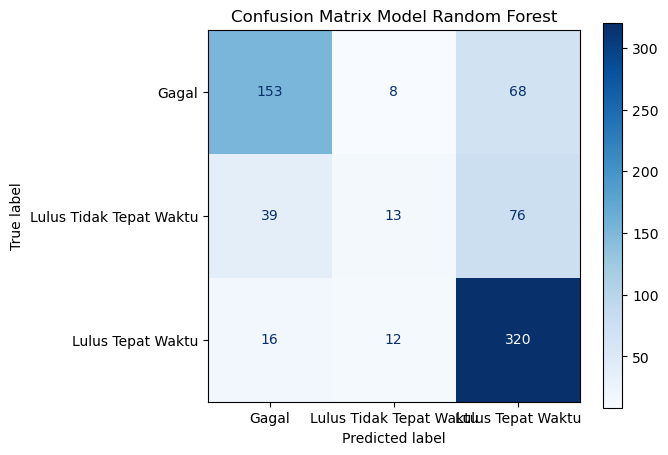

In [43]:
# 3) Visualisasi Confusion Matrix

# versi teks
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# versi plot
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=target_names, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("Confusion Matrix Model Random Forest")
plt.grid(False)
plt.show()

### 6.0.1 Analisis Fitur Paling Berpengaruh (Feature Importance)

**Random Forest** memungkinkan kita melihat fitur mana yang memiliki
pengaruh terbesar dalam proses pengambilan keputusan model untuk
memprediksi kelulusan mahasiswa.



In [44]:
# Mendapatkan nilai importance fitur
importances = rf_model.feature_importances_
feature_names = X.columns

# Membuat series dan mengambil 10 fitur teratas
feat_importances = pd.Series(importances, index=feature_names)
top_features = feat_importances.sort_values(ascending=False).head(10)

# Tampilkan tabel markdown untuk 10 fitur teratas
print("Fitur | Importance Score")
print("------|----------------")
for feature, score in top_features.items():
    print(f"| {feature} | {score:.4f} |")


Fitur | Importance Score
------|----------------
| IP Semester 2 | 0.1843 |
| IP Semester 1 | 0.1327 |
| Nilai Ujian Masuk | 0.0923 |
| Nilai SMA | 0.0845 |
| Usia saat mendaftar | 0.0772 |
| Status pembayaran semester terakhir_Sudah | 0.0497 |
| Beasiswa_Ya | 0.0280 |
| Jenis Kelamin_Wanita | 0.0215 |
| Pindahan_Ya | 0.0187 |
| Pekerjaan Ibu_Pegawai Swasta | 0.0177 |


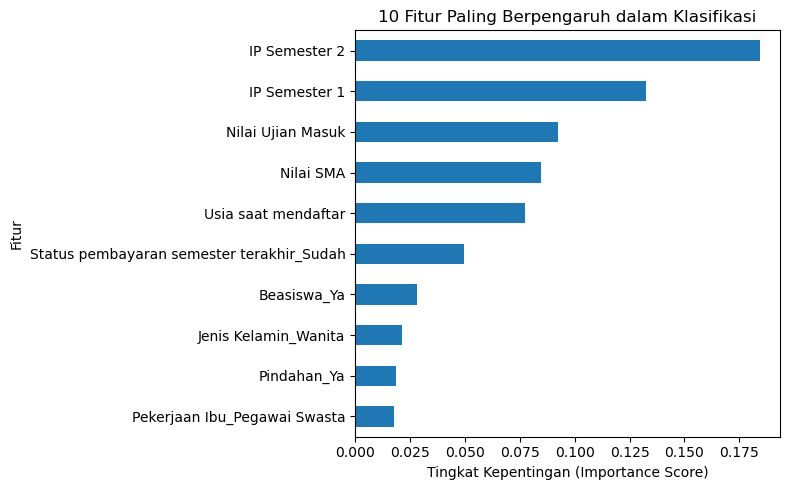

In [45]:
# Visualisasi horizontal bar plot
plt.figure(figsize=(8, 5))
top_features.plot(kind='barh').invert_yaxis()
plt.title("10 Fitur Paling Berpengaruh dalam Klasifikasi")
plt.xlabel("Tingkat Kepentingan (Importance Score)")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

# 7. Kesimpulan (Task 10)

Berdasarkan hasil pemodelan dan evaluasi menggunakan algoritma **Random
Forest**, kita dapat menarik beberapa kesimpulan penting:

1.  **Konsistensi Performa Model:** Rata-rata akurasi *5-Fold Cross
    Validation* pada data *training* adalah **72,31%**, sedangkan
    akurasi pada data *testing* adalah **69,00%**. Selisih penurunan
    performa yang tipis (~3,3%) mengindikasikan adanya sedikit
    *overfitting* ringan, namun secara umum model masih stabil dan
    memiliki kemampuan *generalisasi* yang cukup wajar.
2.  **Analisis Kualitas Klasifikasi Per-Kelas:**
    - **Lulus Tepat Waktu (Mayoritas):** Menunjukkan kinerja terbaik
      dengan tingkat sensitivitas (*Recall*) mencapai **92%**. Model
      sangat andal dalam mendeteksi mahasiswa yang dapat lulus tepat
      waktu (320 dari 348 mahasiswa berhasil diklasifikasikan dengan
      benar).
    - **Gagal (Kritis):** Memiliki performa deteksi dini yang cukup
      andal dengan tingkat ketepatan (*Precision*) **74%** dan
      sensitivitas (*Recall*) **67%** (153 dari 229 mahasiswa). Hal ini
      memberikan jaminan bahwa sebagian besar mahasiswa yang berisiko
      gagal dapat diidentifikasi secara dini.
    - **Lulus Tidak Tepat Waktu (Minoritas - Isu Kritis):** Model
      mengalami kesulitan yang signifikan pada kelas transisi ini,
      dengan *Recall* hanya **10%** (hanya 13 dari 128 mahasiswa) dan
      *f1-score* **16%**. Matrix kebingungan (*confusion matrix*)
      menunjukkan sebagian besar mahasiswa kelas ini salah
      diklasifikasikan sebagai `Lulus Tepat Waktu` (76) atau `Gagal`
      (39). Hal ini menunjukkan bahwa pembobotan kelas
      (`class_weight='balanced'`) saja belum cukup untuk membantu model
      membedakan karakteristik kelas transisi ini dari dua kelas ekstrem
      lainnya.
3.  **Variabel Penentu Utama Kelulusan:** Hasil *Feature Importance*
    memperkuat temuan bahwa performa akademis di tahun pertama adalah
    faktor penentu terbesar. Dua fitur teratas adalah **`IP Semester 2`
    (18,43%)** dan **`IP Semester 1` (13,27%)**. Faktor pendukung
    lainnya meliputi `Nilai Ujian Masuk` (9,23%), `Nilai SMA` (8,45%),
    dan `Usia saat mendaftar` (7,72%). Kondisi finansial berupa status
    pelunasan SPP (`Status pembayaran semester terakhir`) menempati
    posisi keenam dengan nilai kepentingan 4,97%.
4.  **Implikasi dan Rekomendasi Aksi:** Wali akademik dapat menggunakan
    model ini dengan tingkat kepercayaan tinggi untuk membedakan dua
    skenario ekstrem (mahasiswa yang pasti lulus tepat waktu vs
    mahasiswa yang berisiko tinggi gagal). Namun, model harus dibaca
    secara hati-hati terkait kategori mahasiswa yang lulus
    lambat/terlambat karena tingginya tingkat *false negative* (terlewat
    deteksi). Untuk pengembangan sistem selanjutnya, disarankan mencoba
    teknik optimasi *hiperparameter*, algoritma *boosting* (seperti
    XGBoost/LightGBM), atau menguji metode penanganan ketimbang kelas
    lainnya seperti SMOTE khusus pada kelas minoritas tersebut.

# 8. Lampiran

## 8.1 Diagnostik Python

In [46]:
import IPython as ipy
print(ipy.sys_info())

{'commit_hash': 'f5e51b8',
 'commit_source': 'installation',
 'default_encoding': 'utf-8',
 'ipython_path': '/var/home/nord/ContainerHomes/ubuntu-bigdata/miniconda3/envs/machine-learning-tugas/lib/python3.14/site-packages/IPython',
 'ipython_version': '9.11.0',
 'os_name': 'posix',
 'platform': 'Linux-6.19.14-101.fc44.x86_64-x86_64-with-glibc2.39',
 'sys_executable': '/var/home/nord/ContainerHomes/ubuntu-bigdata/miniconda3/envs/machine-learning-tugas/bin/python',
 'sys_platform': 'linux',
 'sys_version': '3.14.4 | packaged by Anaconda, Inc. | (main, Apr 14 2026, '
                '17:07:44) [GCC 14.3.0]'}
